# Load Data

In [12]:
import sys
from pathlib import Path

PROJECT_ROOT = Path(r"C:\Users\maxan\OneDrive\Desktop\0. Personal Projects\market-intelligence-pipeline")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

In [13]:
import pandas as pd
import numpy as np
import duckdb

from src.config import (
    DATABASE_PATH,
    ROLLING_WINDOWS,
    LAGGED_WINDOWS,
    MA_WINDOWS,
    TICKERS,
    START_DATE,
    END_DATE
)

from src.features import (
    build_price_feature_columns
)

CALENDAR = "no_calendar"


def pull_calendar_table(table_name: str, calendar: str) -> pd.DataFrame:

    print("[START] Connecting to database...")

    con = duckdb.connect(DATABASE_PATH)

    print(f"[START] Reading {table_name}")

    df = con.sql(f"""
    
        SELECT *
        FROM {table_name}

    """).df()

    print(f"[DONE] Read {table_name}")

    con.close()

    print(f"[START] Building {CALENDAR} required columns...")

    base_cols = [
        "ticker",
        "date",
        "open",
        "high",
        "low",
        "close",
        "adj_close",
        "volume"
    ]

    feature_columns = build_price_feature_columns(
        calendars = [CALENDAR],
        rolling_windows = ROLLING_WINDOWS,
        lagged_windows = LAGGED_WINDOWS,
        ma_windows = MA_WINDOWS
    )

    expected_columns = base_cols + list(feature_columns.keys())

    calendar_df = df[expected_columns].copy()

    print(f"[DONE] Filtered to {CALENDAR}")

    calendar_df["date"] = pd.to_datetime(calendar_df["date"])

    calendar_df = calendar_df.sort_values(["ticker", "date"])

    print(f"[DONE] Prepared and sorted table")

    return calendar_df

In [ ]:
df = pull_calendar_table(
    table_name = "price_features", 
    calendar = CALENDAR
    )

print(f"[STEP] Loaded price_features table selecting {CALENDAR} columns")
print(df.head(10))
print(df.columns)

[START] Connecting to database...
[START] Reading price_features
[DONE] Read price_features
[START] Building no_calendar required columns...


KeyboardInterrupt: 

: 

In [ ]:
table_count = 0
graph_count = 0

# Rolling Volatility by Ticker

Graph: 1


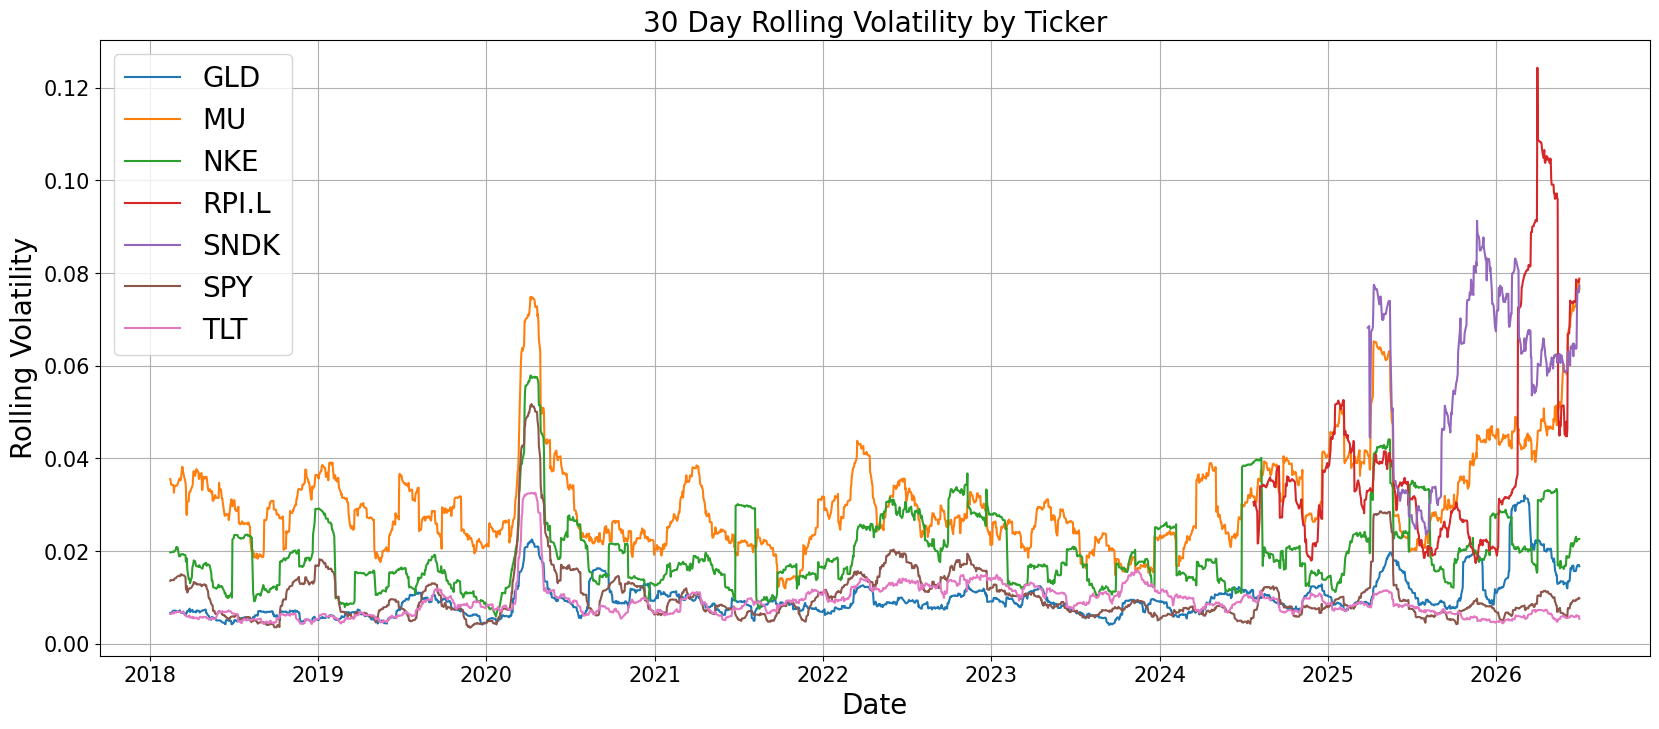

In [ ]:
import matplotlib.pyplot as plt

df_1 = df.copy()

ticker = "ticker"
date="date"
rolling_volatility = f"rolling_30d_volatility_{CALENDAR}"

plt.figure(figsize=(20,8))

for asset, group in df_1.groupby(ticker):

    plt.plot(group[date], group[rolling_volatility], label = asset)

plt.legend(fontsize=20)
plt.title("30 Day Rolling Volatility by Ticker", fontsize=20)
plt.xlabel("Date", fontsize = 20)
plt.xticks(fontsize=15)
plt.ylabel("Rolling Volatility", fontsize=20)
plt.yticks(fontsize=15)
plt.grid()

graph_count += 1
print(f"Graph {graph_count}:")
plt.show()



# Max Drawdown by Ticker

In [ ]:
df_2 = df.copy()

drawdown = f"drawdown_{CALENDAR}"
date = "date"
ticker = "ticker"

def recovery_after_drawdown(df):

    trough_idx = df[drawdown].idxmin()
    trough_row = df.loc[trough_idx]

    trough_date = trough_row[date]
    max_drawdown = trough_row[drawdown]

    after_trough = df[df[date] > trough_date]

    recovery = after_trough[after_trough[drawdown] >= -0.000001].head(1)

    if recovery.empty:
        recovery_date = pd.NaT
        recovery_days = pd.NA
    
    else:
        recovery_date = recovery[date].iloc[0]
        recovery_days = (recovery_date - trough_date).days

    return pd.Series({
        "trough_date": trough_date,
        "max_drawdown": max_drawdown,
        "recovery_date": recovery_date,
        "recovery_days": recovery_days
    })

recovery_summary = (
    df_2.groupby(ticker).apply(recovery_after_drawdown)
)

table_count += 1
print(f"Table {table_count}:")

display(recovery_summary)


plt.figure(figsize=(20,8))

for asset, group in df_2.groupby(ticker):

    group = group.sort_values(date)

    line, = plt.plot(group[date], group[drawdown], label=asset)
    colour = line.get_color()

    max_dd_idx = group[drawdown].idxmin()
    max_dd_row = group.loc[max_dd_idx]

    max_dd_date = max_dd_row[date]
    max_dd_value = max_dd_row[drawdown]

    plt.axhline(
        y = max_dd_value,
        color = colour,
        linestyle = "--",
        linewidth = 1.5,
        alpha = 1
    )

    plt.axvline(
        x = max_dd_date,
        colour = colour,
        linestyle = "--",
        linewidth = 1.5,
        alpha = 1
    )

    plt.scatter(
        max_dd_date,
        max_dd_value,
        colour = colour,
        s = 100,
        zorder = 5
    )

plt.axhline(0, color = "black", linewidth = 1)

plt.title("Drawdown by Ticker", fontsize=30)
plt.xlabel("Date", fontsize=20)
plt.ylabel("Drawdown", fontsize=20)
plt.legend(fontsize=14)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.grid()

group_count += 1
print(f"Graph {graph_count}:")

plt.show()


# Drawdown Over Time

# Risk Across Assets